In [1]:
import sys
import os

# Adds the parent directory to the search path
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

In [2]:
import xtrack as xt
import numpy as np
import os
import matplotlib.pyplot  as plt
import matplotlib.patches as patches
import xpart as xp
import xobjects as xo
import math
import constants


In [3]:
# %% create environment, parameters and first simple cells & structures
n=4

pdr = xt.Environment()
pdr.particle_ref = xt.Particles(kinetic_energy0=2.86e9, mass0 = xt.ELECTRON_MASS_EV)

E0 = constants.E0; VRF = constants.VRF # beam energy in eV and RF voltage (1 cavity) in V

pdr.vars({'l_cell': 3.40,'l_bend': 0.40,'l_bendDS': 0.55,'dl_noben': 0.25, 'l_quad': 0.30,
  'l_drift': '(l_cell - 2*l_bend - 2*l_quad)/4.','dl_drift': -0.15, 'dl_trans': 0.00,
  'l_doub':  0.25, 'l_tripl': 3.00, 'l_trips': 0.40, 'l_sext': 0.10, })



pdr.vars({'N_cells_S': 8,'hBarc' : '6.283185307/(6*(2*N_cells_S*l_bend + l_bendDS))',
  'kQFarc': 2.9478, 'kQDarc':-2.9231,'kQFarcM': 2.8846, 'kQDarcM':-2.7567, 
  'kQFDS': 2.8042, 'kQDDS':-2.2858, 'kQFDoub': 3.9170, 'kQDDoub':-2.5190, 
  'kQFtr': 4.4429, 'kQDtr':-2.4723,  } )

U0 = (0.88463e-31)*E0**4*(2.*np.pi)/(6*(2*pdr['N_cells_S']*pdr['l_bend'] + pdr['l_bendDS']) )

pdr.new('Bend', xt.Bend, length='l_bend', angle='hBarc*l_bend', k0_from_h=True, 
         edge_entry_angle='hBarc*l_bend/2', edge_exit_angle='hBarc*l_bend/2')
pdr.new('QFarc',  xt.Quadrupole, length='l_quad',    k1='kQFarc' )
pdr.new('QFarcH', xt.Quadrupole, length='l_quad/2.', k1='kQFarc' )
pdr.new('Drarc',  xt.Drift,      length='l_drift' )
pdr.new('DrarcS', xt.Drift,      length='l_drift + dl_drift' )
pdr.new('QDarc',  xt.Quadrupole, length='l_quad',    k1='kQDarc' )
pdr.new('QFarcM', xt.Quadrupole, length='l_quad',    k1='kQFarcM' )
pdr.new('QDarcM', xt.Quadrupole, length='l_quad',    k1='kQDarcM' )
pdr.new('BendDS', xt.Bend, length='l_bendDS', angle='hBarc*l_bendDS', k0_from_h=True, 
         edge_entry_angle='hBarc*l_bendDS/2', edge_exit_angle='hBarc*l_bendDS/2')
pdr.new('QFDS',   xt.Quadrupole, length='l_quad',    k1='kQFDS' )
pdr.new('QDDS',   xt.Quadrupole, length='l_quad',    k1='kQDDS' )
pdr.new('DrDSL',  xt.Drift,      length='2*l_drift + l_bend + dl_noben' )
pdr.new('DrTrans',xt.Drift,      length='l_drift + dl_trans' )
pdr.new('QFDoub', xt.Quadrupole, length='l_quad',    k1='kQFDoub' )
pdr.new('QDDoub', xt.Quadrupole, length='l_quad',    k1='kQDDoub' )
pdr.new('DrDoub', xt.Drift,      length='l_doub' )

pdr.new('QFtr',    xt.Quadrupole, length='l_quad',    k1='kQFtr' )
pdr.new('QFtrH',   xt.Quadrupole, length='l_quad/2.', k1='kQFtr' )
pdr.new('QDtr',    xt.Quadrupole, length='l_quad',    k1='kQDtr' )
pdr.new('QDtrH',   xt.Quadrupole, length='l_quad',    k1='kQDtr' )
pdr.new('DrTripl', xt.Drift,      length='l_tripl' )
pdr.new('DrTrips', xt.Drift,      length='l_trips' )


'DrTrips'

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xplt/hooks.py:31: RuntimeWarning: Failed to register formatters with pint: No module named 'pint'
  warnings.warn(f"Failed to register formatters with pint: {e}", RuntimeWarning)


3.4
3.3999999999999995
4.7


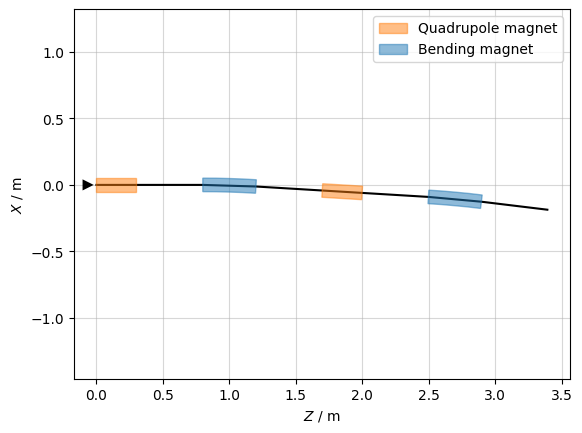

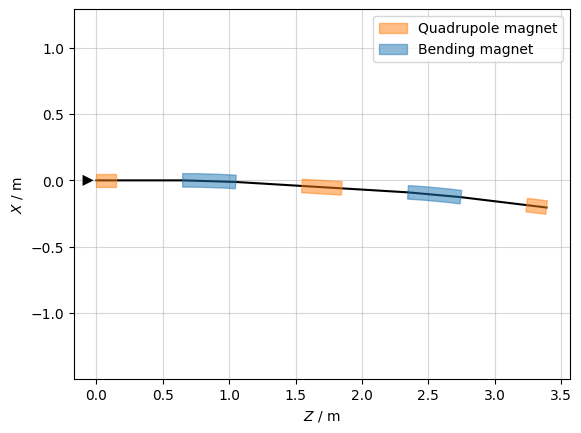

In [4]:
# just an arc cell
cell_arcS = pdr.new_line( length='l_cell', 
    components =[ 
    pdr.new('QF_cell_arc',    'QFarc',at='0*l_drift + 0.5*l_quad + 0.0*l_bend'),
    pdr.new('Bend1_cell_arc', 'Bend', at='1*l_drift + 1.0*l_quad + 0.5*l_bend'),
    pdr.new('QD_cell_arc',    'QDarc',at='2*l_drift + 1.5*l_quad + 1.0*l_bend'),
    pdr.new('Bend2_cell_arc', 'Bend', at='3*l_drift + 2.0*l_quad + 1.5*l_bend'),
    ])
cell_arcS.survey().plot()
print(cell_arcS.get_length())
cell_arc = pdr.new_line( components = [ 
   pdr.new('QF_cell_arcH1',  'QFarcH' ), pdr.place( 'Drarc' ),
   pdr.new('Bend1_cell_arcH','Bend' ),   pdr.place( 'Drarc' ),
   pdr.new('QD_cell_arcH',   'QDarc' ),  pdr.place( 'Drarc' ),
   pdr.new('Bend2_cell_arcH','Bend' ),   pdr.place( 'Drarc' ),
   pdr.new('QF_cell_arcH2',  'QFarcH' ), 
   ])
cell_arc.survey().plot()
print(cell_arc.get_length())
# triplet starting with 
cell_tr = pdr.new_line(
    components = [
    pdr.new('QF_cell_trH1', 'QFtrH',    at='0*l_trips + 0.25*l_quad + 0.0*l_tripl'),
    pdr.new('QD_cell_tr1',  'QDtr',     at='1*l_trips + 1.00*l_quad + 0.0*l_tripl'),
    pdr.new('Mkr_cell_tr',   xt.Marker, at='1*l_trips + 1.50*l_quad + 0.5*l_tripl'),
    pdr.new('QD_cell_tr2',  'QDtr',     at='1*l_trips + 2.00*l_quad + 1.0*l_tripl'),
    pdr.new('QF_cell_trH2', 'QFtrH',    at='2*l_trips + 2.75*l_quad + 1.0*l_tripl')
    ])

print(cell_tr.get_length())

In [5]:
def makesextant ( name, fall ):
    comps = [ ]
    for ind in range( pdr['N_cells_S'] - 1 ):  # regular arc cells
       comps = comps + [ pdr.place('Drarc'), pdr.new('Bend1_' + name + str(ind+1), 'Bend')]
       comps = comps + [ pdr.place('Drarc'), pdr.new('QDA_' + name + str(ind+1), 'QDarc')]
       comps = comps + [ pdr.place('Drarc'), pdr.new('Bend2_' + name + str(ind+1), 'Bend')]
       comps = comps + [ pdr.place('Drarc'), pdr.new('QFA_' + name + str(ind+1), 'QFarc')]

    # Replace last QF and add last arc cell (matching quads) "by hand"

    comps[-1] = pdr.new('QFA_M' + name + str(pdr['N_cells_S']-1), 'QFarcM' )
    comps = comps + [pdr.place('DrarcS'),pdr.new('Bend1_' + name + str(pdr['N_cells_S']), 'Bend')]
    comps = comps + [pdr.place('Drarc'), pdr.new('QDA_M' + name + str(pdr['N_cells_S']), 'QDarcM')]
    comps = comps + [pdr.place('Drarc'), pdr.new('Bend2_' + name + str(pdr['N_cells_S']), 'Bend')]

    # Add dispersion suppressor
    comps = comps + [pdr.place('Drarc'), pdr.new('QFDS_' + name, 'QFDS') ]
    comps = comps + [pdr.place('DrDSL'), pdr.new('QDDS_' + name, 'QDDS') ]
    comps = comps + [pdr.place('Drarc'), pdr.new('BendDS_' + name, 'BendDS')]

    # Add doublet matching 
    comps = comps + [pdr.place('DrTrans'), pdr.new('QFDoub_' + name, 'QFDoub')]
    comps = comps + [pdr.place('DrDoub'), pdr.new('QDDoub_' + name, 'QDDoub')]   
    comps = comps + [pdr.place('DrTripl'), pdr.new('QDTrip_' + name + '1', 'QDtr')]  

    if fall == 'symm':
       comps = [ pdr.new('QFA_' + name + 'CH', 'QFarcH' ) ] + comps
       comps = comps + [ pdr.place('DrTrips'), pdr.new('QFTripC_' + name + '2H', 'QFtrH')]

    elif fall == 'right':
       comps = [ pdr.new('QFA_' + name + 'C', 'QFarc'  ) ] + comps + [ pdr.place('DrTrips') ]
    elif fall == 'left':
       comps = comps + [pdr.place('DrTrips'), pdr.new('QFTripC_' + name + '2', 'QFtr') ]
       comps = list( reversed(comps) )

    else:
       print( '=====> choice for sextant version incorrect <=====' )
       quit()

    return pdr.new_line( components = comps )


In [6]:
arc1R = makesextant( 'xR', 'symm' )
arc1R_sliced = arc1R.select()
arc1R_sliced.cut_at_s( np.linspace(.05, arc1R.get_length()-.05, int(arc1R.get_length()/.05-.5)) )
arc1R.insert( pdr.new('CtrS1_xR1', xt.Marker ), at='(l_tripl+l_quad)/2', from_='QDDoub_xR' )


Slicing line:   0%|          | 0/77 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/77 [00:00<?, ?it/s]

In [7]:

# One period from center of arc to center of arc
period = makesextant( 'PR', 'symm') + ( -makesextant( 'PL', 'symm') )
period_sliced = period.select()
period_sliced.cut_at_s( np.linspace(.05, period.get_length()-.05, int(period.get_length()/.05-.5)) )


Slicing line:   0%|          | 0/154 [00:00<?, ?it/s]

In [8]:

# Full ring without X-poles, RF and wigglers
ring  = makesextant( '1R', 'right') + makesextant( '2L', 'left') + makesextant( '2R', 'right') + makesextant( '3L', 'left') + makesextant( '3R', 'right') + makesextant( '1L', 'left')
fRev = 1./(ring.twiss(method='4d').T_rev0)
fRF  = fRev*round(4.e8/fRev)  # at integer harmonics and close to 400 MHz
pdr.new('RFCav',  xt.Cavity, length=1.5, frequency=fRF, voltage=VRF, 
        lag=(180/np.pi)*(np.pi - np.arcsin(U0/VRF)) - 1.8 ) 
ring.insert( pdr.new('RFCav_1', 'RFCav'), at='(l_tripl+l_quad)/2', from_='QDDoub_1R' )
ring.configure_radiation(model='mean')
ring.configure_bend_model(edge='full')

Slicing line:   0%|          | 0/456 [00:00<?, ?it/s]

In [9]:
# %% Routine for several matchings in a row for 90 degrees arc cells and given tunes

# Matching of arc cell
cell_arc_opt = cell_arc.match( method='4d', solve=True, verbose=False,
    vary=[
        xt.VaryList(['kQFarc', 'kQDarc', 'kQFarcM'], step=1e-4),    ],
    targets=[
        xt.TargetSet(qx=0.25, qy=0.25, tol=1.0e-6, tag='end'), # just twice the same 
        xt.TargetSet(mux=0.25, muy=0.25, at=xt.END, tol=1.0e-6)]  )

# Triplet cell to chosen betatron functions
cell_tr_opt = cell_tr.match( method='4d', solve=True,
    vary=[ # use individual Vary commands instead of List for arc cell
        xt.Vary('kQFtr', step=1e-4 ),
        xt.Vary('kQDtr', step=1e-4),    ],
    targets=[
        xt.TargetSet(betx=2.50, bety=2.50, at='Mkr_cell_tr', tol=1.0e-6, tag='betas')] )

def matchingWP( qx, qy, MakePlot=False ):
    cell_arc_opt.run_jacobian(10)
    cell_arc_tw = cell_arc.twiss( method='4d' )
    arc1R_opttune = arc1R.match( method='4d', solve=True, verbose=False,
                 betx=cell_arc_tw.betx[0], alfx=cell_arc_tw.alfx[0],
                 bety=cell_arc_tw.bety[0], alfy=cell_arc_tw.alfy[0],
                 dx=cell_arc_tw.dx[0],     dpx=cell_arc_tw.dpx[0],
            vary=[ xt.VaryList(['kQFarcM', 'kQDarcM'], step=1e-4),
                   xt.VaryList(['kQFDS', 'kQDDS'], step=1e-4),
                   xt.VaryList(['kQFDoub', 'kQDDoub'], step=1e-4),
                   xt.VaryList(['kQFtr', 'kQDtr'], step=1e-4), ],
            targets=[ xt.TargetSet(dx=0, dpx=0, at=xt.END, tol=1.0e-9),
                      xt.TargetSet(mux=qx/6, muy=qy/6, at=xt.END, 
                                   tol=1.0e-9, weight=.1, tag='phase'),
                      xt.TargetSet(alfx=0, alfy=0, at=xt.END, tol=1.0e-9),
                      xt.TargetSet(alfx=0, alfy=0, at='CtrS1_xR1', 
                                   tol=1.0e-9, weight=10.) ])
    arc1R_opttune.run_jacobian(50)
    if MakePlot:
       arc1R.twiss( method='4d',
                    betx=cell_arc_tw.betx[0], alfx=cell_arc_tw.alfx[0],
                    bety=cell_arc_tw.bety[0], alfy=cell_arc_tw.alfy[0],
                    dx=cell_arc_tw.dx[0],     dpx=cell_arc_tw.dpx[0],).plot()

        
# Matching sequence for sextant with beta at center of straights fixed
def matchingBeta( betxS, betyS, MakePlot=False ): #, **kwargs ):
    cell_arc_opt.run_jacobian(10)
    cell_arc_tw = cell_arc.twiss( method='4d' )
    cell_tr_opt.targets[0].value, cell_tr_opt.targets[1].value = betxS, betyS
    cell_tr_opt.run_jacobian(10)
    cell_tr_tw = cell_tr.twiss( method='4d' )
    arc1R_opt = arc1R.match( method='4d', solve=True,
                 betx=cell_arc_tw.betx[0], alfx=cell_arc_tw.alfx[0],
                 bety=cell_arc_tw.bety[0], alfy=cell_arc_tw.alfy[0],
                 dx=cell_arc_tw.dx[0],     dpx=cell_arc_tw.dpx[0],
            vary=[ xt.VaryList(['kQFarcM', 'kQDarcM'], step=1e-4),
                   xt.VaryList(['kQFDS', 'kQDDS'], step=1e-4),
                   xt.VaryList(['kQFDoub', 'kQDDoub'], step=1e-4) ],
            targets=[ xt.TargetSet(dx=0, dpx=0, at=xt.END, tol=1.0e-9),
                      xt.TargetSet(alfx=0, alfy=0, at=xt.END, tol=1.0e-9),
                      xt.TargetSet(betx=cell_tr_tw.betx[0], bety=cell_tr_tw.bety[0],
                                   at=xt.END, tol=1.0e-9) ])
    arc1R_opt.run_jacobian(10)
    if MakePlot:
       arc1R.twiss( method='4d',
                    betx=cell_arc_tw.betx[0], alfx=cell_arc_tw.alfx[0],
                    bety=cell_arc_tw.bety[0], alfy=cell_arc_tw.alfy[0],
                    dx=cell_arc_tw.dx[0],     dpx=cell_arc_tw.dpx[0],).plot() 
       

matchingWP(*constants.WP)

cell_tr_tw = cell_tr.twiss(method='4d')
mid_idx = len(cell_tr_tw.betx) // 2
betxS = cell_tr_tw.betx[mid_idx]
betyS = cell_tr_tw.bety[mid_idx]
matchingBeta( betxS, betyS, MakePlot=False )

                                             0              
Optimize - start penalty: 0.8838                            
Matching: model call n. 21 penalty = 2.0237e-09              
Optimize - end penalty:  2.02373e-09                            
                                             10               
Optimize - start penalty: 0                                  
Matching: model call n. 23 penalty = 0.0000e+00              
Optimize - end penalty:     0                            
                                             
Optimize - start penalty: 1.698e-09                         
Matching: model call n. 2 penalty = 1.6976e-09              
Optimize - end penalty:  1.6976e-09                            
                                             
Optimize - start penalty: 1.698e-09                         
Matching: model call n. 4 penalty = 1.6976e-09              
Optimize - end penalty:  1.6976e-09                            


Slicing line:   0%|          | 0/458 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/460 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/462 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/464 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/466 [00:00<?, ?it/s]

...

Slicing line:   0%|          | 0/194 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/196 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/198 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/200 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/202 [00:00<?, ?it/s]

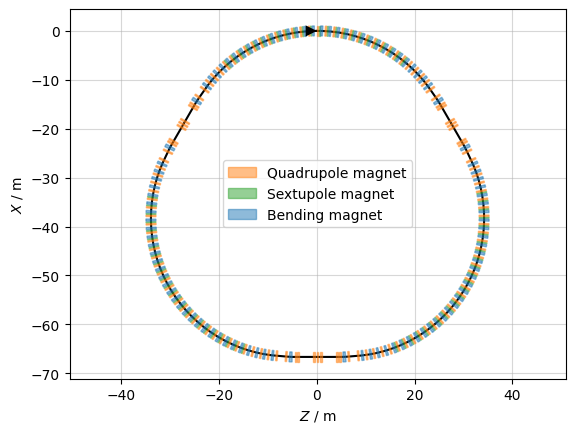

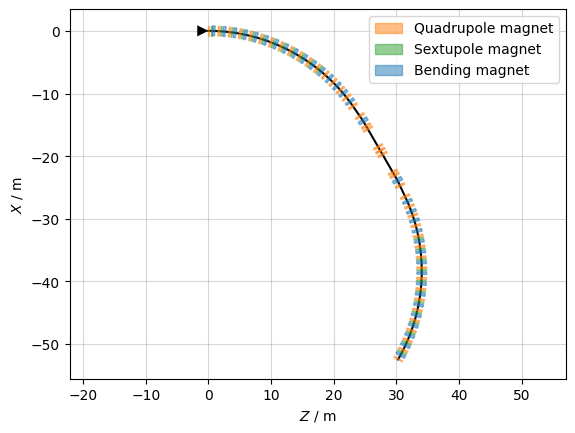

In [10]:
pdr.vars( { 'k2XF3arc': 0.00, 'k2XD3arc': 0.00, } )  # Sextupoles - two families defined here
pdr.new('XF3arc',  xt.Sextupole, length='l_sext',    k2='k2XF3arc' )
pdr.new('XD3arc',  xt.Sextupole, length='l_sext',    k2='k2XD3arc' )

ringS3 = ring.select()   # should make a copy?
for elem in (['1L6', '1L5', '1L4', '1L3', '1L2', '1L1', '1R1', '1R2', '1R3', '1R4', '1R5', '1R6',
              '2L6', '2L5', '2L4', '2L3', '2L2', '2L1', '2R1', '2R2', '2R3', '2R4', '2R5', '2R6',
              '3L6', '3L5', '3L4', '3L3', '3L2', '3L1', '3R1', '3R2', '3R3', '3R4', '3R5', '3R6',]):

  ringS3.insert( pdr.new('XD3arc_' + elem, 'XD3arc'), 
            at = '(l_drift+l_quad)/2', from_='QDA_' + elem  )



for elem in (['1L6', '1L5', '1L4', '1L3', '1L2', '1L1', '1RC', '1R1', '1R2', '1R3', '1R4', '1R5',
              '2L6', '2L5', '2L4', '2L3', '2L2', '2L1', '2RC', '2R1', '2R2', '2R3', '2R4', '2R5',
              '3L6', '3L5', '3L4', '3L3', '3L2', '3L1', '3RC', '3R1', '3R2', '3R3', '3R4', '3R5' ]):

  ringS3.insert( pdr.new('XF3arc_' + elem, 'XF3arc'), 
            at = '(l_drift+l_quad)/2', from_='QFA_' + elem )

ringS3.survey().plot()

periodS3 = period.select()
for elem in ['PL6', 'PL5', 'PL4', 'PL3', 'PL2', 'PL1', 'PR1', 'PR2', 'PR3', 'PR4', 'PR5', 'PR6']:
  periodS3.insert( pdr.new('XD3arc_' + elem, 'XD3arc'), 
              at='(l_drift+l_quad)/2', from_='QDA_' + elem )

for elem in ['PL6', 'PL5', 'PL4', 'PL3', 'PL2', 'PL1', 'PRCH', 'PR1', 'PR2', 'PR3', 'PR4', 'PR5']:
  periodS3.insert( pdr.new('XF3arc_' + elem, 'XF3arc'), 
              at ='(l_drift+l_quad)/2', from_='QFA_' + elem )

periodS3.survey().plot()



#  Just generate some output

periodS3_sliced = periodS3.select()
periodS3_sliced.cut_at_s( np.linspace(.05, period.get_length()-.05, int(period.get_length()/.05-.5)) )



In [11]:
'''ringS1_chroma = ringS1.match( method='4d', solve=True,
    vary = [ xt.VaryList(['k2XF1arc', 'k2XD1arc'], step=1e-4 )],
    targets = [ xt.TargetSet(dqx=0, dqy=0, tol=1e-5 ) ]  )



ringS1_chroma.run_jacobian(10)'''

"ringS1_chroma = ringS1.match( method='4d', solve=True,\n    vary = [ xt.VaryList(['k2XF1arc', 'k2XD1arc'], step=1e-4 )],\n    targets = [ xt.TargetSet(dqx=0, dqy=0, tol=1e-5 ) ]  )\n\n\n\nringS1_chroma.run_jacobian(10)"

In [12]:
def ChromCorrect(ksf, ksd, MakePlot=False):
        
    opt_chrom = ringS3.match(
        solve=True,
        verbose=False,
        method='6d',
        vary=xt.VaryList([ksf, ksd], step=1e-4),
        targets=[
            # Global goals
            xt.Target(dqx=0, tol=1e-5),
            xt.Target(dqy=0, tol=1e-5),
            
            
        ])
    opt_chrom.target_status()
    opt_chrom.run_jacobian(10)
    opt_chrom.target_status()
    # Print the final matched strengths

    print(f"Matched kSF: {pdr.vars['k2XF3arc']._get_value():.6f}")
    print(f"Matched kSD: {pdr.vars['k2XD3arc']._get_value():.6f}")   

ChromCorrect('k2XF3arc', 'k2XD3arc', MakePlot=False)

Target status:               nalty = 6.6775e-07              
id state tag tol_met       residue   current_val target_val description                      
0  ON    dqx    True    6.6775e-07    6.6775e-07          0 'dqx', val=0, tol=1e-05, weight=1
1  ON    dqy    True   1.42109e-10   1.42109e-10          0 'dqy', val=0, tol=1e-05, weight=1
Target status:               nalty = 6.6775e-07              
id state tag tol_met       residue   current_val target_val description                      
0  ON    dqx    True    6.6775e-07    6.6775e-07          0 'dqx', val=0, tol=1e-05, weight=1
1  ON    dqy    True   1.42109e-10   1.42109e-10          0 'dqy', val=0, tol=1e-05, weight=1
Matched kSF: 112.839273
Matched kSD: -170.666015


In [13]:
configs = {
    "arc1R": arc1R,
    "cell_arc": cell_arc,
    "cell_tr": cell_tr,
    "period": periodS3,
    "ring": ringS3,
    "pdr": pdr
}

for name, line in configs.items():
    filename = f"json_files/{name}_{n}.json"
    line.to_json(filename)
    print(f"Successfully saved: {filename}")

Successfully saved: json_files/arc1R_4.json
Successfully saved: json_files/cell_arc_4.json
Successfully saved: json_files/cell_tr_4.json
Successfully saved: json_files/period_4.json
Successfully saved: json_files/ring_4.json
Successfully saved: json_files/pdr_4.json
